In [29]:
from brian2 import *
import matplotlib.pyplot as plt
from plottingTools import *

In [30]:
class Gaussian_Input_Generator:
    def __init__(self,
                 n,
                 amp=0,
                 mu=0,
                 sigma=1,
                 noise=False,
                 normalised=True,
                 verbose=False):
        
        self.n=n
        self.m=amp  #amplitude
        self.mu=mu #peak position (preferred direction of the corresponding neuron (theta in gradi))
        self.sigma=sigma #refers to the certainty of the cue
        self.noise=noise
        self.normalised=normalised
        self.x=np.linspace(0, 360, self.n, endpoint=True)
        self.y=None
        self.verbose=verbose        
    
    def generate_cue(self):
    
        # Create a wrap based on the number of neurons
        wraps = np.arange(-self.n/2, self.n/2+1)
        gaussianComponent = np.exp(-0.5 * ((self.x[:,np.newaxis]-self.mu+wraps*360) /self.sigma)**2)
        wrappedGaussian = self.m * np.sum(gaussianComponent, axis=1)
        normalizationTerm=1/(self.sigma*((2*pi)**0.5))

        y=wrappedGaussian
        
        if self.noise:
            y=self.add_noise(y)
            
        if self.normalised:
            y=y*normalizationTerm
        
        if self.verbose:
            for index, (angle, value) in enumerate(zip(self.x, y)):
                print('Gaussian', index, 'at', angle, 'has value', value)
            
            print('The angle should theoretically be', self.mu,
                '.\nThe peak is at', self.x[np.argmax(y)],
                '. The respective neuron is', np.argmax(y))
            
        self.y = y
        return y
    
    
    def plot_gaussians_polar(self):
        # Generate the wrapped Gaussian values
        gaussian_values = self.generate_cue()
        
        plot_on_circle(self.x, gaussian_values, title='Wrapped Gaussian on a Circle',
                       legend_label='Wrapped Gaussian', legend_kwargs={'loc': 'upper right'})


    def add_noise(self,I):
        I_noisy=I+normal(0,1,len(self.x))*2e-2
        return I_noisy
    
    def to_brian2_neuron_group(self):
        input_gen = NeuronGroup(self.n, 'I : 1', threshold='I > 0', reset='I = 0', method='exact')
        if self.y is None:
            input_gen.I = self.generate_cue()
        else:
            input_gen.I = self.y
        return input_gen

Gaussian 0 at 0.0 has value 6.027618870481579e-283
Gaussian 1 at 18.94736842105263 has value 4.0529171019221805e-227
Gaussian 2 at 37.89473684210526 has value 3.16156978234804e-177
Gaussian 3 at 56.84210526315789 has value 1.4306089636749205e-133
Gaussian 4 at 75.78947368421052 has value 3.755106254096489e-96
Gaussian 5 at 94.73684210526315 has value 5.717506108596555e-65
Gaussian 6 at 113.68421052631578 has value 5.049799824369455e-40
Gaussian 7 at 132.6315789473684 has value 2.5871690495313093e-21
Gaussian 8 at 151.57894736842104 has value 7.68880010027021e-09
Gaussian 9 at 170.52631578947367 has value 0.013254869348585701
Gaussian 10 at 189.4736842105263 has value 0.013254869348585845
Gaussian 11 at 208.42105263157893 has value 7.688800100270484e-09
Gaussian 12 at 227.36842105263156 has value 2.587169049531475e-21
Gaussian 13 at 246.3157894736842 has value 5.049799824369814e-40
Gaussian 14 at 265.2631578947368 has value 5.717506108597368e-65
Gaussian 15 at 284.2105263157895 has valu

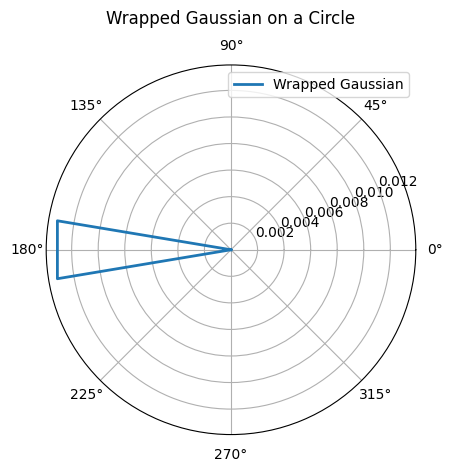

In [ ]:
# num_neurons = 20
# duration = 100*ms

# gaussian_gen = Gaussian_Input_Generator(num_neurons, amp=1, mu=180, sigma=5, noise=False, normalised=True ,verbose=True)
# gaussian_gen.plot_gaussians_polar()

In [ ]:
# input_gen = gaussian_gen.to_brian2_neuron_group()
# spike_monitor_input = SpikeMonitor(input_gen, name="spike_input")
# run(duration)

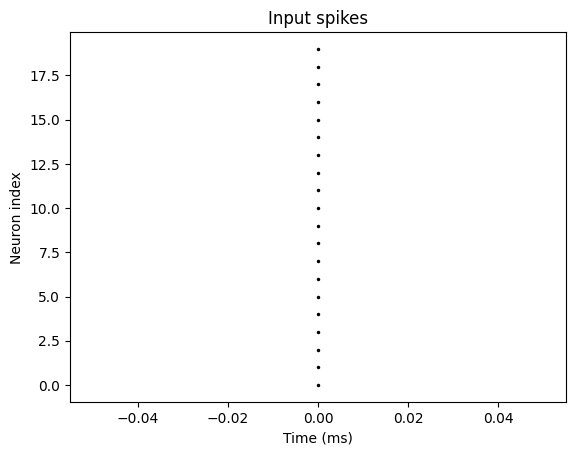

In [ ]:
# # plotting
# plt.figure()
# plt.plot(spike_monitor_input.t/ms, spike_monitor_input.i, '.k', ms=3)
# plt.xlabel('Time (ms)')
# plt.ylabel('Neuron index')
# plt.title('Input spikes')
# plt.show()
